# 2. Updating beliefs with Bayes

**What this notebook answers:** how should a forecast change when new evidence arrives, and how
much should we trust our own model compared with the market price?

> **A note on the data.** Fed decisions are rare and we do not yet have the FRED macro data
> (the API key is pending). So the numbers in the worked examples here are **illustrative and
> hand-picked**, chosen to show how the maths behaves. They are labelled wherever they appear.
> When the real data lands, the same functions run unchanged.

In [1]:
import sys
sys.path.insert(0, ".")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.special import expit, logit
import _style as st
from pmq.models.dirichlet import DirichletBelief, counts_from_outcome
from pmq.models.pooling import pool_binary, fit_weight_on_model

st.setup()

## 2.1 Bayes' rule in one picture

You hold a belief. You see evidence. Bayes' rule says how to change your mind:

$$\underbrace{P(\text{belief} \mid \text{evidence})}_{\text{posterior: what you think now}} \;\propto\; \underbrace{P(\text{evidence} \mid \text{belief})}_{\text{likelihood: how well the belief predicted it}} \times \underbrace{P(\text{belief})}_{\text{prior: what you thought before}}$$

The everyday version uses **odds**. If an event has probability $p$, its odds are $p/(1-p)$.

$$\text{posterior odds} = \text{prior odds} \times \text{likelihood ratio}$$

The *likelihood ratio* answers: "how many times more likely was I to see this evidence if the event is
going to happen than if it isn't?" A ratio of 2 means the evidence is twice as likely in the
world where the event happens.

**Worked example (illustrative).** The market says a rate cut is 30% likely. A surprisingly weak
jobs report arrives, which we judge to be 3 times as likely in a world where the Fed cuts. What should the cut probability be now?

In [2]:
prior = 0.30
likelihood_ratio = 3.0                         # illustrative judgement
prior_odds = prior / (1 - prior)
post_odds = prior_odds * likelihood_ratio
posterior = post_odds / (1 + post_odds)
print(f"prior {prior:.0%} -> odds {prior_odds:.3f}; x{likelihood_ratio:g} -> odds {post_odds:.3f}; posterior {posterior:.1%}")

prior 30% -> odds 0.429; x3 -> odds 1.286; posterior 56.3%


**Why work in log-odds.** Taking logs turns the multiplication into an addition:
$\text{logit}(p_{\text{new}}) = \text{logit}(p_{\text{old}}) + \ln(\text{LR})$, where $\text{logit}(p)=\ln\frac{p}{1-p}$.
Every piece of evidence just adds or subtracts a fixed amount. The chart shows why that matters:
the same evidence moves a 50% forecast a lot and a 95% forecast a little, because the extremes are "harder to shift".

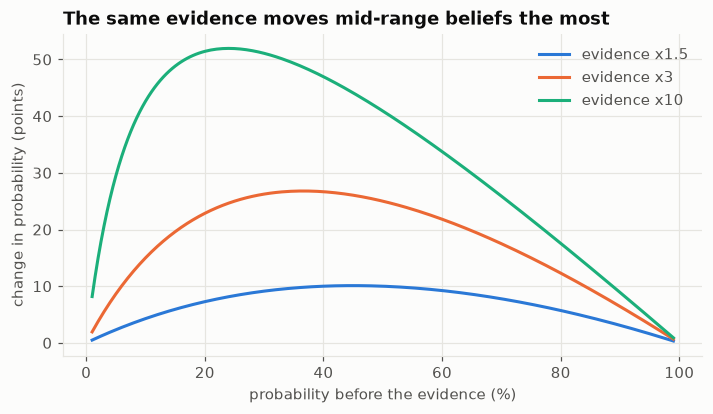

In [3]:
p0 = np.linspace(0.01, 0.99, 197)
fig, ax = plt.subplots()
for lr, colour in [(1.5, st.BLUE), (3, st.ORANGE), (10, st.AQUA)]:
    new = expit(logit(p0) + np.log(lr))
    ax.plot(p0 * 100, (new - p0) * 100, color=colour, label=f"evidence x{lr:g}")
ax.set_xlabel("probability before the evidence (%)"); ax.set_ylabel("change in probability (points)")
ax.set_title("The same evidence moves mid-range beliefs the most"); ax.legend()
plt.show()

## 2.2 A belief over several outcomes: the Dirichlet

For a Fed meeting there are several outcomes, not two. The natural way to hold a belief over
K outcomes is the **Dirichlet distribution**. Think of it as **pseudo-counts**:

* `[2, 6, 2]` for (cut, hold, hike) means *"I hold this view as firmly as if I had watched 10 meetings and seen 2 cuts, 6 holds, 2 hikes."*
* The **total** (here 10) is how firmly you hold it. Bigger total, harder to move.

The update rule is delightfully simple: **each time you observe an outcome, add 1 to its pseudo-count.**

$$\text{prior } \text{Dir}(\alpha) \;+\; \text{observed counts } n \;\longrightarrow\; \text{posterior } \text{Dir}(\alpha + n)$$

The forecast for the next event is just $\alpha_k / \sum_j \alpha_j$. (Statisticians call this
*conjugacy*: the answer has the same shape as the question, so you can update forever.)

Below: an **illustrative** prior of `[2, 6, 2]`, then 8 events arriving one after another. The lines
are the forecast; the shaded bands are the 90% **credible interval**, meaning "given everything so far, there is a 90% chance the true
probability sits in this range". Watch the bands narrow as evidence piles up.

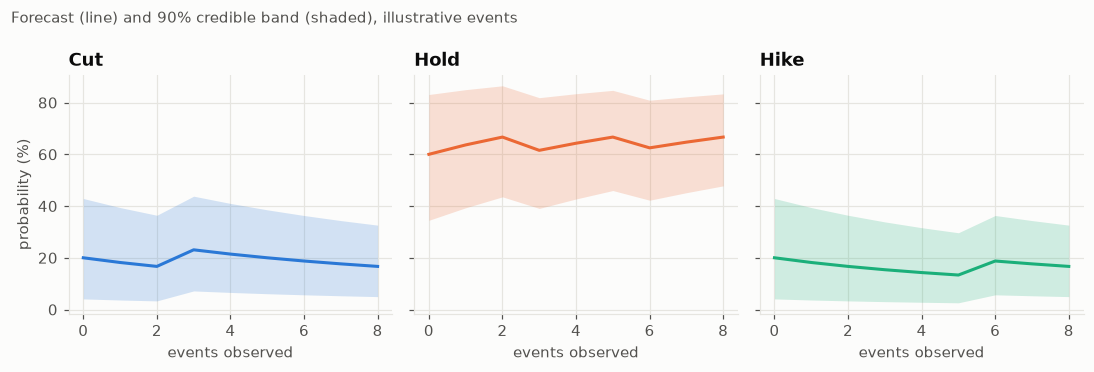

final pseudo-counts: [ 3. 12.  3.] -> forecast [16.7 66.7 16.7]


In [4]:
labels = ("Cut", "Hold", "Hike")
belief = DirichletBelief(labels, np.array([2.0, 6.0, 2.0]))
sequence = [1, 1, 0, 1, 1, 2, 1, 1]             # ILLUSTRATIVE observed outcomes (0=cut,1=hold,2=hike)

means, lows, highs = [belief.mean()], [belief.credible_interval()[:, 0]], [belief.credible_interval()[:, 1]]
for outcome in sequence:
    belief = belief.update(counts_from_outcome(outcome, 3))
    means.append(belief.mean()); ci = belief.credible_interval()
    lows.append(ci[:, 0]); highs.append(ci[:, 1])
means, lows, highs = map(np.array, (means, lows, highs))

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4), sharey=True)
steps = np.arange(len(means))
for k, (ax, colour) in enumerate(zip(axes, [st.BLUE, st.ORANGE, st.AQUA])):
    ax.fill_between(steps, lows[:, k] * 100, highs[:, k] * 100, color=colour, alpha=0.2, lw=0)
    ax.plot(steps, means[:, k] * 100, color=colour)
    ax.set_title(labels[k]); ax.set_xlabel("events observed")
axes[0].set_ylabel("probability (%)")
fig.suptitle("Forecast (line) and 90% credible band (shaded), illustrative events", x=0.01, ha="left", fontsize=10, color=st.INK_SOFT)
plt.tight_layout(); plt.show()
print("final pseudo-counts:", belief.alpha, "-> forecast", (belief.mean() * 100).round(1))

## 2.3 Which prior was better? Model comparison for free

Suppose two forecasters start from different priors. The **evidence** (or marginal likelihood) of a
prior is the probability it assigned to what actually happened. Bayes gives this a closed form
for the Dirichlet, and it automatically punishes both over-confidence and vagueness:

$$P(\text{data} \mid \alpha) \;\propto\; \frac{\Gamma(A)}{\Gamma(A + N)} \prod_k \frac{\Gamma(\alpha_k + n_k)}{\Gamma(\alpha_k)}, \qquad A = \textstyle\sum_k \alpha_k,\; N = \textstyle\sum_k n_k$$

Comparing two priors is then a ratio, the **Bayes factor**. A factor of 10 is usually called
"strong" support.

In [5]:
data = np.array([1, 6, 1])                      # ILLUSTRATIVE: 8 meetings, mostly holds
priors = {
    "Sceptic: flat":            DirichletBelief.from_probabilities(labels, [1/3, 1/3, 1/3], strength=6),
    "Hold-heavy, modest":       DirichletBelief.from_probabilities(labels, [0.15, 0.7, 0.15], strength=6),
    "Hold-heavy, over-sure":    DirichletBelief.from_probabilities(labels, [0.01, 0.98, 0.01], strength=60),
}
rows = [{"prior": name, "log evidence": b.log_evidence(data)} for name, b in priors.items()]
ev = pd.DataFrame(rows).set_index("prior")
ev["Bayes factor vs flat"] = np.exp(ev["log evidence"] - ev.loc["Sceptic: flat", "log evidence"])
ev.round(3)

,log evidence,Bayes factor vs flat
prior,,
Sceptic: flat,-7.853,1.000
"Hold-heavy, modest",-6.770,2.955
"Hold-heavy, over-sure",-9.532,0.187


The modest hold-heavy prior wins: it expected mostly holds and got mostly holds, and it left room
for the one cut and one hike. The over-sure prior *also* expected holds, but it was so confident
that the surprises cost it heavily. Bayes rewards being right **and** appropriately humble.

## 2.4 Combining our model with the market price

We usually have two forecasts of the same event: the market's and our model's. Averaging them
directly has a flaw: it can never be more confident than the more confident of the two. If two
independent sources both say 90%, a sensible combined view is *higher* than 90%.

The fix is to average in **log-odds** (a *logarithmic opinion pool*), with weight $w$ on the model:

$$\text{logit}(p_{\text{pooled}}) = w \cdot \text{logit}(p_{\text{model}}) + (1-w)\cdot \text{logit}(p_{\text{market}})$$

$w = 0$ means "trust the market entirely" and $w = 1$ means "trust the model entirely".
Example (illustrative): model says 70%, market says 40%.

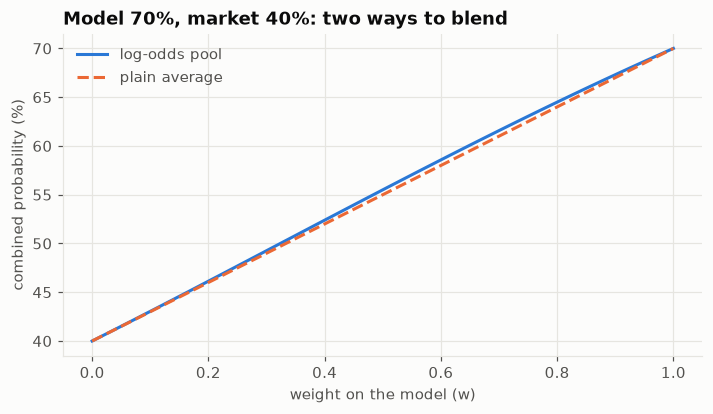

w = 0.5 -> log-odds pool 55.5%, plain average 55.0%


In [6]:
w = np.linspace(0, 1, 101)
pooled = pool_binary(0.70, 0.40, 0)  # warm-up call
pooled = np.array([float(pool_binary(0.70, 0.40, x)) for x in w])
linear = w * 0.70 + (1 - w) * 0.40

fig, ax = plt.subplots()
ax.plot(w, pooled * 100, color=st.BLUE, label="log-odds pool")
ax.plot(w, linear * 100, color=st.ORANGE, ls="--", label="plain average")
ax.set_xlabel("weight on the model (w)"); ax.set_ylabel("combined probability (%)")
ax.set_title("Model 70%, market 40%: two ways to blend"); ax.legend()
plt.show()
print(f"w = 0.5 -> log-odds pool {pool_binary(0.70, 0.40, 0.5) * 100:.1f}%, plain average {55.0:.1f}%")

### How is $w$ chosen? From how well each source has done in the past

We choose the $w$ that would have scored best (lowest log loss) on past resolved events. The
crucial point is that **an honest result can be $w \approx 0$**: it means the market already contains
everything the model knows, and the right move is to defer to it.

To show the mechanism works, here are two **synthetic** worlds (simulated, not real markets).
In the first, our model is pure noise; in the second it is far more accurate than a noisy market.

In [7]:
rng = np.random.default_rng(3)
n = 4000
truth = rng.uniform(0.1, 0.9, n)                     # the true probabilities in this simulated world
y = (rng.random(n) < truth).astype(float)            # what actually happened

worlds = {
    "Model is noise, market is sharp":       (rng.uniform(0.05, 0.95, n), np.clip(truth + rng.normal(0, 0.02, n), 0.02, 0.98)),
    "Model is sharp, market is noisy":       (np.clip(truth + rng.normal(0, 0.02, n), 0.02, 0.98), np.clip(truth + rng.normal(0, 0.25, n), 0.02, 0.98)),
    "Both moderately informative":           (np.clip(truth + rng.normal(0, 0.12, n), 0.02, 0.98), np.clip(truth + rng.normal(0, 0.12, n), 0.02, 0.98)),
}
rows = []
for name, (model, market) in worlds.items():
    wt, ll = fit_weight_on_model(model, market, y)
    rows.append({"world (synthetic)": name, "fitted weight on model": round(wt, 2)})
pd.DataFrame(rows).set_index("world (synthetic)")

,fitted weight on model
world (synthetic),
"Model is noise, market is sharp",0.00
"Model is sharp, market is noisy",0.97
Both moderately informative,0.49


The fitted weight moves exactly as it should: near 0 when the model adds nothing, near 1 when it is
better than the market, in between when both help. When the real data arrives, this same
function will tell us, without guesswork, how much the model deserves.

## Recap

* Bayes' rule in odds form: **posterior odds = prior odds × likelihood ratio**; in log-odds evidence just adds.
* For several outcomes, the **Dirichlet** stores a belief as pseudo-counts; updating is adding the counts you observe.
* The **credible interval** shrinks as evidence accumulates, so uncertainty is explicit, never hidden.
* **Log-evidence** compares priors by how well they predicted reality.
* **Log-odds pooling** blends model and market; the weight is learned from history and can honestly be zero.

**Next:** notebook 3 grades forecasts with proper scoring rules and turns an edge into a position size.